

## **K-Means Clustering Analysis**

### **Objective**

Apply **K-Means clustering** technique to student performance data across three academic years to identify natural groupings of students based on their characteristics and academic performance metrics.

---

### **K-Means Parameters**

* **n_clusters (K):** Number of clusters to generate
* **init:** Method used to initialize centroids (e.g., k-means++)
* **max_iter:** Maximum number of iterations
* **random_state:** Seed for reproducibility

---

### **Methodology**

* Data Preparation and Feature Selection
* Feature Scaling using StandardScaler
* Optimal Cluster Selection using Elbow Method and Silhouette Score
* K-Means Application and Evaluation
* Suitability Assessment for each year's data






The objective of this analysis is to apply **K-Means clustering** to student performance data across three academic years in order to identify natural groups of students based on their academic characteristics and performance metrics.

The goal is to discover hidden patterns among students, such as groups with similar performance levels or learning behaviors, without using predefined labels. This helps in understanding student profiles and analyzing performance trends across different academic years.


Data Preparation & Feature Selection


In [1]:
import pandas as pd

# 🔹 Load datasets using relative paths (portable for everyone)
df1 = pd.read_csv("../data/1y_final_clean_encoded.csv")  # first-year dataset
df2 = pd.read_csv("../data/2y_final_clean_encoded.csv")  # second-year dataset
df3 = pd.read_csv("../data/3y_final_clean_encoded.csv")  # third-year dataset

# 🔹 Check first 5 rows
print("1Y Data:")
print(df1.head())
print("\n2Y Data:")
print(df2.head())
print("\n3Y Data:")
print(df3.head())


1Y Data:
   record_id  gender  study_year  bac_specialty  study_hours_per_week  \
0          1       1           2              2                     0   
1          2       0           2              0                     1   
2          3       0           2              2                     0   
3          4       1           2              0                     0   
4          5       1           2              1                     0   

   preferred_study_place  preferred_study_time  learning_methods  \
0                      0                     0                22   
1                      2                     0                54   
2                      3                     0                14   
3                      2                     2                54   
4                      2                     0                54   

   study_resources  uses_planner  ...  1y english 2  1y intensive english  \
0               16             0  ...             2               

In [3]:
# ==============================
# STEP 2: DATA PREPARATION & FEATURE SELECTION
# ==============================

import pandas as pd

# 🔹 Load datasets using relative paths (portable for everyone)
df1 = pd.read_csv("../data/1y_final_clean_encoded.csv")  # First-year
df2 = pd.read_csv("../data/2y_final_clean_encoded.csv")  # Second-year
df3 = pd.read_csv("../data/3y_final_clean_encoded.csv")  # Third-year

# 🔹 Remove non-informative or redundant columns
# Columns like IDs or repeated year info do not help clustering
drop_cols = [
    "record_id",
    "study_year",
    "year_ordinal",
    "inferred_year_from_grades"
]

df1 = df1.drop(columns=drop_cols, errors="ignore")
df2 = df2.drop(columns=drop_cols, errors="ignore")
df3 = df3.drop(columns=drop_cols, errors="ignore")

# 🔹 Keep only numeric columns (K-Means works with numbers only)
df1_numeric = df1.select_dtypes(include="number")
df2_numeric = df2.select_dtypes(include="number")
df3_numeric = df3.select_dtypes(include="number")

# 🔹 Final feature matrices for clustering
X1 = df1_numeric.copy()  # Features for first-year clustering
X2 = df2_numeric.copy()  # Features for second-year clustering
X3 = df3_numeric.copy()  # Features for third-year clustering

# 🔹 Print shapes to confirm everything is ready
print("Feature shapes ready for clustering:")
print("1Y:", X1.shape)
print("2Y:", X2.shape)
print("3Y:", X3.shape)



Feature shapes ready for clustering:
1Y: (210, 53)
2Y: (101, 60)
3Y: (12, 45)


In [4]:
# ==============================
# STEP 3: FEATURE SCALING
# ==============================

from sklearn.preprocessing import StandardScaler

# 🔹 Initialize scaler
scaler = StandardScaler()

# 🔹 Scale features for each year
X1_scaled = pd.DataFrame(scaler.fit_transform(X1), columns=X1.columns)
X2_scaled = pd.DataFrame(scaler.fit_transform(X2), columns=X2.columns)
X3_scaled = pd.DataFrame(scaler.fit_transform(X3), columns=X3.columns)

# 🔹 Quick check: means should be ~0, std ~1
print("1Y scaled mean/std (first 5 columns):\n", X1_scaled.iloc[:, :5].agg(['mean', 'std']).round(2))
print("2Y scaled mean/std (first 5 columns):\n", X2_scaled.iloc[:, :5].agg(['mean', 'std']).round(2))
print("3Y scaled mean/std (first 5 columns):\n", X3_scaled.iloc[:, :5].agg(['mean', 'std']).round(2))


1Y scaled mean/std (first 5 columns):
       gender  bac_specialty  study_hours_per_week  preferred_study_place  \
mean    -0.0            0.0                  -0.0                   -0.0   
std      1.0            1.0                   1.0                    1.0   

      preferred_study_time  
mean                   0.0  
std                    1.0  
2Y scaled mean/std (first 5 columns):
       gender  bac_specialty  study_hours_per_week  preferred_study_place  \
mean     0.0           -0.0                   0.0                    0.0   
std      1.0            1.0                   1.0                    1.0   

      preferred_study_time  
mean                  -0.0  
std                    1.0  
3Y scaled mean/std (first 5 columns):
       gender  bac_specialty  study_hours_per_week  preferred_study_place  \
mean    0.00          -0.00                 -0.00                   0.00   
std     1.04           1.04                  1.04                   1.04   

      preferred_study_

In [5]:
# ==============================
# STEP 4: PCA for Dimensionality Reduction & Visualization
# ==============================

from sklearn.decomposition import PCA

# 🔹 Initialize PCA to reduce to 2 components (for 2D plotting)
pca = PCA(n_components=2)

# 🔹 Apply PCA to each year's scaled features
X1_pca = pd.DataFrame(pca.fit_transform(X1_scaled), columns=["PC1", "PC2"])  # 1Y PCA
X2_pca = pd.DataFrame(pca.fit_transform(X2_scaled), columns=["PC1", "PC2"])  # 2Y PCA
X3_pca = pd.DataFrame(pca.fit_transform(X3_scaled), columns=["PC1", "PC2"])  # 3Y PCA

# 🔹 Check how much variance is retained
print("1Y PCA explained variance ratio:", pca.explained_variance_ratio_.sum().round(2))
print("2Y PCA explained variance ratio:", pca.explained_variance_ratio_.sum().round(2))
print("3Y PCA explained variance ratio:", pca.explained_variance_ratio_.sum().round(2))

# 🔹 Optional: inspect first 5 PCA points
print("1Y PCA sample:\n", X1_pca.head())


1Y PCA explained variance ratio: 0.46
2Y PCA explained variance ratio: 0.46
3Y PCA explained variance ratio: 0.46
1Y PCA sample:
         PC1       PC2
0 -3.250196 -0.780189
1 -4.453935  0.259583
2 -3.755283 -0.416069
3 -1.789598 -2.581786
4 -3.148937 -1.133471


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

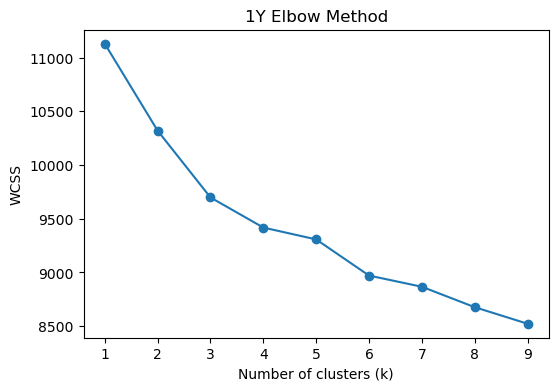

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

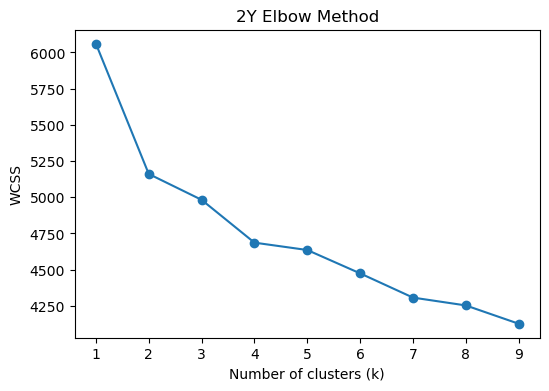

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

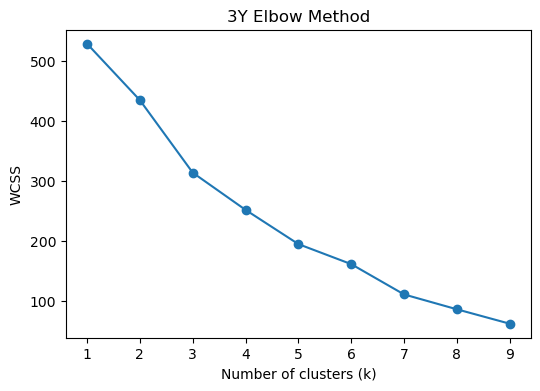

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


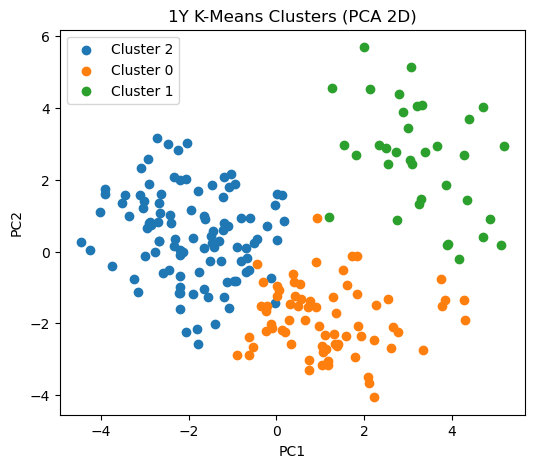

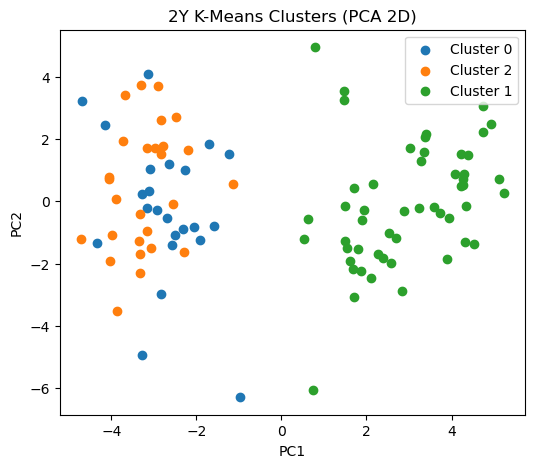

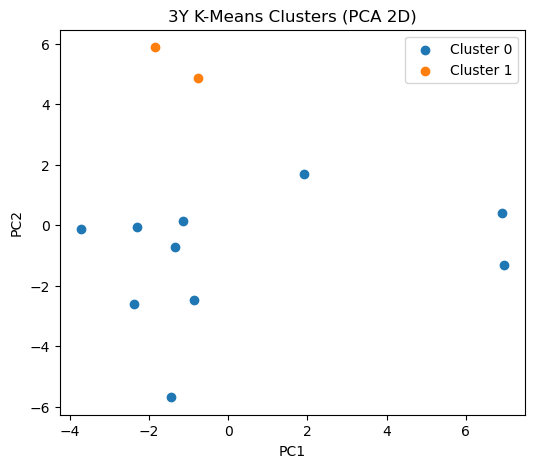

In [6]:
# ==============================
# STEP 5: K-MEANS CLUSTERING
# ==============================

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 🔹 Function to find optimal k using Elbow Method
def plot_elbow(X_scaled, year_label):
    wcss = []
    K_range = range(1, 10)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
    plt.figure(figsize=(6,4))
    plt.plot(K_range, wcss, marker='o')
    plt.title(f"{year_label} Elbow Method")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("WCSS")
    plt.show()

# 🔹 Plot elbow for each year
plot_elbow(X1_scaled, "1Y")
plot_elbow(X2_scaled, "2Y")
plot_elbow(X3_scaled, "3Y")

# 🔹 Fit K-Means (choose k after checking elbow, here we use example k=3)
k1, k2, k3 = 3, 3, 2  # example, adjust based on elbow
kmeans1 = KMeans(n_clusters=k1, random_state=42).fit(X1_scaled)
kmeans2 = KMeans(n_clusters=k2, random_state=42).fit(X2_scaled)
kmeans3 = KMeans(n_clusters=k3, random_state=42).fit(X3_scaled)

# 🔹 Save cluster labels
X1_pca['Cluster'] = kmeans1.labels_
X2_pca['Cluster'] = kmeans2.labels_
X3_pca['Cluster'] = kmeans3.labels_

# 🔹 Plot clusters in PCA 2D space
def plot_clusters(X_pca, year_label):
    plt.figure(figsize=(6,5))
    for c in X_pca['Cluster'].unique():
        subset = X_pca[X_pca['Cluster']==c]
        plt.scatter(subset['PC1'], subset['PC2'], label=f"Cluster {c}")
    plt.title(f"{year_label} K-Means Clusters (PCA 2D)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

plot_clusters(X1_pca, "1Y")
plot_clusters(X2_pca, "2Y")
plot_clusters(X3_pca, "3Y")


In [7]:
print("1Y cluster counts:\n", X1_pca['Cluster'].value_counts())
print("2Y cluster counts:\n", X2_pca['Cluster'].value_counts())
print("3Y cluster counts:\n", X3_pca['Cluster'].value_counts())


1Y cluster counts:
 Cluster
2    103
0     72
1     35
Name: count, dtype: int64
2Y cluster counts:
 Cluster
1    51
2    27
0    23
Name: count, dtype: int64
3Y cluster counts:
 Cluster
0    10
1     2
Name: count, dtype: int64


In [8]:
from sklearn.metrics import silhouette_score

# For 1Y
silhouette_1Y = silhouette_score(X1_scaled, kmeans1.labels_)
print("1Y Silhouette Score:", silhouette_1Y)

# For 2Y
silhouette_2Y = silhouette_score(X2_scaled, kmeans2.labels_)
print("2Y Silhouette Score:", silhouette_2Y)

# For 3Y
silhouette_3Y = silhouette_score(X3_scaled, kmeans3.labels_)
print("3Y Silhouette Score:", silhouette_3Y)


1Y Silhouette Score: 0.07153464266334976
2Y Silhouette Score: 0.08653115984924548
3Y Silhouette Score: 0.13493010767096406
